# 04 — ABP / metadynamics in two dimensions

This notebook studies a two-dimensional metastable diffusion accelerated with
Gaussian adaptive biasing potential (ABP / metadynamics).

The scientific objectives are:

1. represent a genuine two-dimensional metastable landscape;
2. verify that the adaptive bias promotes transitions between the two wells;
3. distinguish the biased simulation clock from the reweighted physical clock;
4. reconstruct the physical equilibrium marginals from the ABP weights;
5. compare the reconstructed marginals with the theoretical Boltzmann law.

The notebook deliberately separates **model definition**, **simulation**,
**post-processing**, and **visualization**. The simulation returns an immutable
`ABPResult`; every figure below is reconstructed from that result.

## 1. Imports and repository paths

The repository `src` directory is added to `sys.path` only to make the notebook
work from a fresh clone. In a development environment installed with
`python -m pip install -e ".[notebook]"`, this insertion is harmless.

In [22]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display


def find_repository_root(start: Path | None = None) -> Path:
    """Locate the repository root from the current working directory."""
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "src").exists():
            return candidate
    raise FileNotFoundError(
        "Repository root not found. Run the notebook from the STAGE repository."
    )


ROOT = find_repository_root()
SRC = ROOT / "src"
ARTIFACTS = ROOT / "artifacts" / "notebook_04"
ARTIFACTS.mkdir(parents=True, exist_ok=True)

if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from stage_escape.abp_abf.abp_bias import gaussian_bias_value
from stage_escape.abp_abf.abp_metadynamics import ABPMetaDynamics
from stage_escape.abp_abf.distribution_analysis import (
    theoretical_marginal_2d,
    weighted_histogram_density,
)
from stage_escape.abp_abf.potential import Potential
from stage_escape.result_io import load_result, save_result

plt.rcParams.update(
    {
        "figure.figsize": (8.0, 5.0),
        "figure.dpi": 120,
        "axes.grid": False,
    }
)

print(f"Repository root: {ROOT}")
print(f"Artifacts:       {ARTIFACTS}")

Repository root: /home/administrateur/Bureau/STAGE
Artifacts:       /home/administrateur/Bureau/STAGE/artifacts/notebook_04


## 2. Physical model

We use the separable bistable potential

$[
V(x,y)=\frac{a}{4}(x^2-1)^2+\frac{k_y}{2}y^2.
]$

The $(x)$-coordinate is the metastable reaction coordinate: the minima are near
$((-1,0))$ and $((1,0))$, separated by the saddle at $((0,0))$. The
$(y)$-coordinate is confined harmonically. This choice makes the two-dimensional
simulation interpretable while still allowing an exact numerical reference for
both equilibrium marginals.

In [23]:
BARRIER_SCALE = 1.0
TRANSVERSE_STIFFNESS = 1.5


def potential_value(point: np.ndarray) -> float:
    """Two-dimensional bistable potential."""
    x, y = np.asarray(point, dtype=float)
    return float(
        0.25 * BARRIER_SCALE * (x**2 - 1.0) ** 2
        + 0.5 * TRANSVERSE_STIFFNESS * y**2
    )


def potential_gradient(point: np.ndarray) -> np.ndarray:
    """Analytic gradient of the bistable potential."""
    x, y = np.asarray(point, dtype=float)
    return np.array(
        [
            BARRIER_SCALE * x * (x**2 - 1.0),
            TRANSVERSE_STIFFNESS * y,
        ],
        dtype=float,
    )


physical_potential = Potential(
    dimension=2,
    function=potential_value,
    first_derivative=potential_gradient,
)

LEFT_MINIMUM = np.array([-1.0, 0.0])
RIGHT_MINIMUM = np.array([1.0, 0.0])
TRANSITION_THRESHOLD = 0.8

assert np.isclose(physical_potential.potential_at(LEFT_MINIMUM), 0.0)
assert np.isclose(physical_potential.potential_at(RIGHT_MINIMUM), 0.0)
assert np.allclose(
    physical_potential.potential_prime_at(LEFT_MINIMUM),
    np.zeros(2),
)

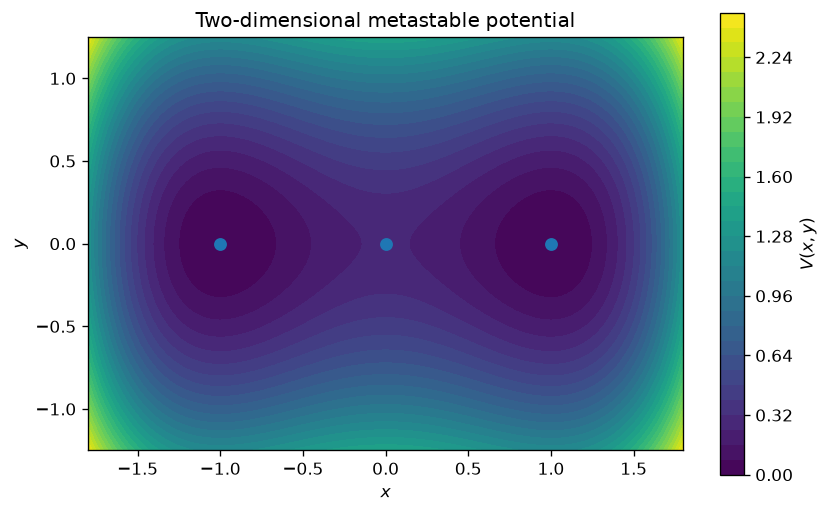

In [24]:
X_RANGE = (-1.8, 1.8)
Y_RANGE = (-1.25, 1.25)

x_grid = np.linspace(*X_RANGE, 181)
y_grid = np.linspace(*Y_RANGE, 141)
X, Y = np.meshgrid(x_grid, y_grid, indexing="xy")
V = (
    0.25 * BARRIER_SCALE * (X**2 - 1.0) ** 2
    + 0.5 * TRANSVERSE_STIFFNESS * Y**2
)

fig, ax = plt.subplots()
contours = ax.contourf(X, Y, V, levels=35)
fig.colorbar(contours, ax=ax, label=r"$V(x,y)$")
ax.scatter(
    [LEFT_MINIMUM[0], RIGHT_MINIMUM[0], 0.0],
    [LEFT_MINIMUM[1], RIGHT_MINIMUM[1], 0.0],
    marker="o",
    s=45,
)
ax.set(
    xlabel=r"$x$",
    ylabel=r"$y$",
    title="Two-dimensional metastable potential",
    xlim=X_RANGE,
    ylim=Y_RANGE,
)
ax.set_aspect("equal")
plt.show()

## 3. Simulation parameters

Two execution modes are provided:

- `quick`: suitable for checking that the notebook and figures work;
- `reference`: longer run intended for report-quality statistics.

A fixed-length trajectory is used instead of stopping at the first transition.
Stopping at the first crossing would be appropriate for a first-passage study,
but it would systematically bias the equilibrium-density estimates developed
later in the notebook.

In [25]:
RUN_MODE = "reference"  # Change to "reference" for the report run.
RUN_SIMULATION = True
SAVE_RESULT = False

CONFIGURATIONS = {
    "quick": {
        "max_steps": 50_000,
        "delta_t": 5.0e-4,
        "D": 5.0e-2,
        "deposition_stride": 200,
        "W": 1.0e-2,
        "sigma": 1.8e-1,
        "seed": 2026,
    },
    "reference": {
        "max_steps": 300_000,
        "delta_t": 5.0e-4,
        "D": 5.0e-2,
        "deposition_stride": 200,
        "W": 1.0e-2,
        "sigma": 1.8e-1,
        "seed": 2026,
    },
}

if RUN_MODE not in CONFIGURATIONS:
    raise ValueError(f"Unknown RUN_MODE: {RUN_MODE!r}")

config = CONFIGURATIONS[RUN_MODE].copy()
RESULT_PREFIX = ARTIFACTS / f"abp_2d_{RUN_MODE}"

display(config)

{'max_steps': 300000,
 'delta_t': 0.0005,
 'D': 0.05,
 'deposition_stride': 200,
 'W': 0.01,
 'sigma': 0.18,
 'seed': 2026}

## 4. Run or load the ABP simulation

`ABPMetaDynamics.run(max_steps=...)` uses a **total** step cap. The simulation
state is owned by the simulation object, while the returned `ABPResult`
contains the immutable trajectory, reweighting factors, Gaussian centers,
clocks, and metadata needed for analysis.

In [26]:
simulation: ABPMetaDynamics | None

if RUN_SIMULATION:
    simulation = ABPMetaDynamics(
        deposition_stride=config["deposition_stride"],
        transition_detector=None,
        delta_t=config["delta_t"],
        dimension=2,
        D=config["D"],
        initial_position=LEFT_MINIMUM,
        b=physical_potential,
        W=config["W"],
        sigma=config["sigma"],
        seed=config["seed"],
        cutoff=5.0,
    )
    result = simulation.run(max_steps=config["max_steps"])

    if SAVE_RESULT:
        save_result(result, RESULT_PREFIX)
        print(f"Saved result to prefix: {RESULT_PREFIX}")
else:
    simulation = None
    result = load_result(RESULT_PREFIX)
    print(f"Loaded result from prefix: {RESULT_PREFIX}")

assert result.dimension == 2
assert result.positions.shape == (result.n_steps + 1, 2)
assert result.weights.shape == (result.n_steps + 1,)
assert np.all(np.isfinite(result.positions))
assert np.all(np.isfinite(result.weights))
assert np.all(result.weights > 0.0)

result

ABPResult(method='abp', positions=array([[-1.        ,  0.        ],
       [-1.00560822,  0.0017011 ],
       [-1.01901162,  0.01156942],
       ...,
       [ 1.05154888,  0.65285346],
       [ 1.0497916 ,  0.65399579],
       [ 1.0566351 ,  0.65585596]], shape=(300001, 2)), delta_t=0.0005, diffusion=0.05, seed=2026, transition_index=None, physical_time=168035192.09093946, termination_reason='max_steps', metadata=mappingproxy({'dimension': 2, 'deposition_stride': 200, 'cutoff': 5.0}), weights=array([1.00000000e+00, 1.00000000e+00, 1.00000000e+00, ...,
       8.18938980e+03, 7.97446592e+03, 7.56167036e+03], shape=(300001,)), centers=array([[-0.97989894,  0.09600882],
       [-0.82227799,  0.0132352 ],
       [-0.93516975, -0.11766927],
       ...,
       [ 1.29164913,  0.76325985],
       [ 1.20696672,  0.61674635],
       [ 1.0566351 ,  0.65585596]], shape=(1500, 2)), bias_height=0.01, bias_width=0.18)

## 5. Scalar diagnostics

The first crossing of \(x=0.8\) is extracted *a posteriori*. This preserves the
full trajectory for equilibrium analysis while still reporting a transition
time from the left well to the right well.

The effective sample size (ESS) quantifies how concentrated the reweighting
factors are. A very small ESS relative to the trajectory length is a warning
that the density estimate is dominated by a small number of heavily weighted
states.

In [27]:
def first_crossing_index(
    positions: np.ndarray,
    *,
    axis: int,
    threshold: float,
) -> int | None:
    indices = np.flatnonzero(positions[:, axis] >= threshold)
    return None if len(indices) == 0 else int(indices[0])


def physical_time_at_index(result, index: int | None) -> float | None:
    if index is None:
        return None
    if index == 0:
        return 0.0
    return float(np.sum(result.weights[1 : index + 1]) * result.delta_t)


first_transition_index = first_crossing_index(
    result.positions,
    axis=0,
    threshold=TRANSITION_THRESHOLD,
)
biased_first_transition_time = (
    None
    if first_transition_index is None
    else first_transition_index * result.delta_t
)
physical_first_transition_time = physical_time_at_index(
    result,
    first_transition_index,
)

scaled_weights = result.weights / np.max(result.weights)
effective_sample_size = float(
    np.sum(scaled_weights) ** 2 / np.sum(scaled_weights**2)
)

summary = {
    "termination_reason": result.termination_reason,
    "steps": result.n_steps,
    "biased_simulated_time": result.simulated_time,
    "reweighted_physical_time": result.physical_time,
    "gaussian_centers": len(result.centers),
    "first_transition_index": first_transition_index,
    "biased_first_transition_time": biased_first_transition_time,
    "physical_first_transition_time": physical_first_transition_time,
    "maximum_weight": float(np.max(result.weights)),
    "effective_sample_size": effective_sample_size,
    "ESS_fraction": effective_sample_size / len(result.weights),
}

display(summary)

{'termination_reason': 'max_steps',
 'steps': 300000,
 'biased_simulated_time': 150.0,
 'reweighted_physical_time': 168035192.09093946,
 'gaussian_centers': 1500,
 'first_transition_index': 39043,
 'biased_first_transition_time': 19.5215,
 'physical_first_transition_time': 2234.2061158757137,
 'maximum_weight': 224968073.44471705,
 'effective_sample_size': 4216.526167520282,
 'ESS_fraction': 0.014055040374933023}

## 6. Trajectory and deposited Gaussian centers

The contour plot checks three points simultaneously:

1. the particle starts in the left metastable well;
2. the adaptive bias lets the trajectory explore the barrier and the other well;
3. Gaussian centers are deposited along the visited part of the landscape.

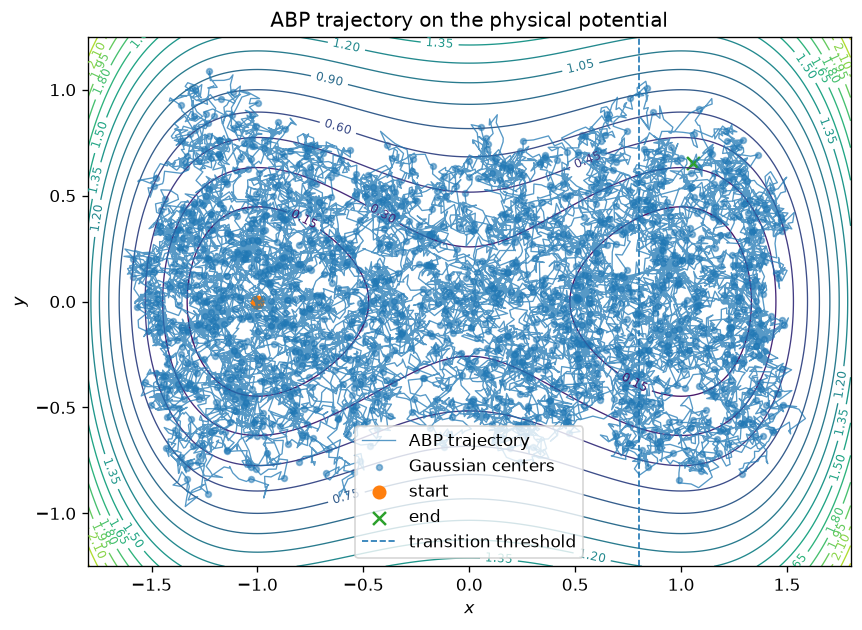

In [28]:
positions = result.positions
plot_stride = max(len(positions) // 15_000, 1)
center_stride = max(len(result.centers) // 1_500, 1)

fig, ax = plt.subplots(figsize=(8.2, 5.8))
contours = ax.contour(X, Y, V, levels=22, linewidths=0.8)
ax.clabel(contours, inline=True, fontsize=7)

ax.plot(
    positions[::plot_stride, 0],
    positions[::plot_stride, 1],
    linewidth=0.8,
    alpha=0.75,
    label="ABP trajectory",
)

if len(result.centers):
    ax.scatter(
        result.centers[::center_stride, 0],
        result.centers[::center_stride, 1],
        s=12,
        alpha=0.5,
        label="Gaussian centers",
    )

ax.scatter(
    positions[0, 0],
    positions[0, 1],
    marker="o",
    s=55,
    label="start",
)
ax.scatter(
    positions[-1, 0],
    positions[-1, 1],
    marker="x",
    s=60,
    label="end",
)
ax.axvline(
    TRANSITION_THRESHOLD,
    linestyle="--",
    linewidth=1.0,
    label="transition threshold",
)

ax.set(
    xlabel=r"$x$",
    ylabel=r"$y$",
    title="ABP trajectory on the physical potential",
    xlim=X_RANGE,
    ylim=Y_RANGE,
)
ax.set_aspect("equal")
ax.legend(loc="best")
plt.show()

## 7. Physical, bias, and effective potentials

The final accumulated bias is reconstructed exclusively from the immutable
result (`centers`, `bias_height`, and `bias_width`). Along the reaction
coordinate \(y=0\), the bias should partially fill the wells and reduce the
effective barrier explored by the dynamics.

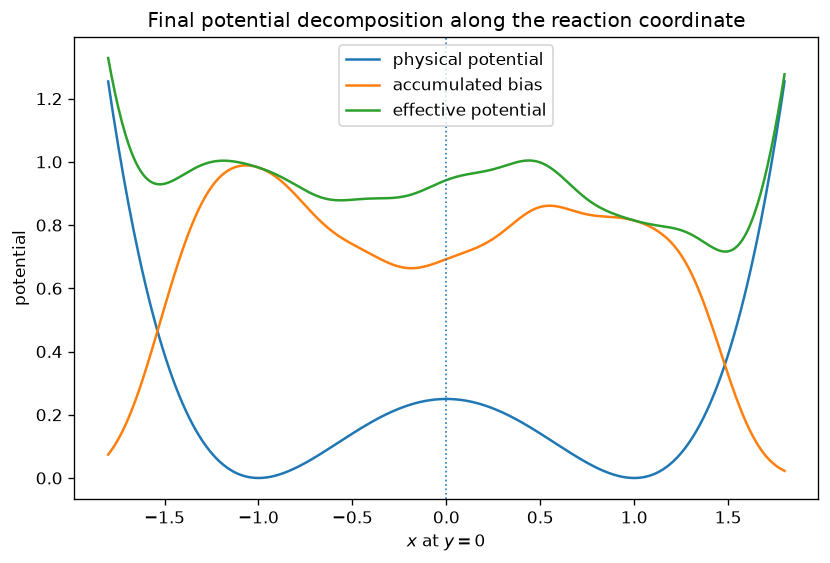

In [29]:
def final_bias_at(point: np.ndarray) -> float:
    return float(
        gaussian_bias_value(
            position=np.asarray(point, dtype=float),
            centers=result.centers,
            height=result.bias_height,
            sigma=result.bias_width,
            cutoff=result.metadata.get("cutoff"),
        )
    )


reaction_coordinate = np.linspace(*X_RANGE, 401)
physical_section = np.array(
    [physical_potential.potential_at([x, 0.0]) for x in reaction_coordinate]
)
bias_section = np.array(
    [final_bias_at(np.array([x, 0.0])) for x in reaction_coordinate]
)
effective_section = physical_section + bias_section

fig, ax = plt.subplots()
ax.plot(reaction_coordinate, physical_section, label="physical potential")
ax.plot(reaction_coordinate, bias_section, label="accumulated bias")
ax.plot(reaction_coordinate, effective_section, label="effective potential")
ax.axvline(0.0, linestyle=":", linewidth=1.0)
ax.set(
    xlabel=r"$x$ at $y=0$",
    ylabel="potential",
    title="Final potential decomposition along the reaction coordinate",
)
ax.legend()
plt.show()

## 8. Reweighted equilibrium marginals

The raw trajectory samples the **biased** dynamics. Consequently, its ordinary
histogram is not expected to follow the physical Boltzmann law.

The `ABPResult.weights` values convert biased residence time into physical
residence time. Weighted histograms should therefore be compared with the
theoretical marginals obtained from

$[
\pi(x,y)\propto \exp\!\left[-V(x,y)/D\right].
]$

Both coordinates are checked: \(x\) tests metastable exploration and \(y\)
tests transverse confinement.

In [30]:
histogram_bins = 80

x_raw_centers, x_raw_density, _, _ = weighted_histogram_density(
    positions[:, 0],
    bins=histogram_bins,
    value_range=X_RANGE,
)
x_weighted_centers, x_weighted_density, _, _ = weighted_histogram_density(
    positions[:, 0],
    weights=result.weights,
    bins=histogram_bins,
    value_range=X_RANGE,
)

y_raw_centers, y_raw_density, _, _ = weighted_histogram_density(
    positions[:, 1],
    bins=histogram_bins,
    value_range=Y_RANGE,
)
y_weighted_centers, y_weighted_density, _, _ = weighted_histogram_density(
    positions[:, 1],
    weights=result.weights,
    bins=histogram_bins,
    value_range=Y_RANGE,
)

theory_x_grid = np.linspace(*X_RANGE, 241)
theory_y_grid = np.linspace(*Y_RANGE, 201)

theory_x_coordinate, theory_x_density = theoretical_marginal_2d(
    physical_potential,
    theory_x_grid,
    theory_y_grid,
    D=result.diffusion,
    axis=0,
)
theory_y_coordinate, theory_y_density = theoretical_marginal_2d(
    physical_potential,
    theory_x_grid,
    theory_y_grid,
    D=result.diffusion,
    axis=1,
)

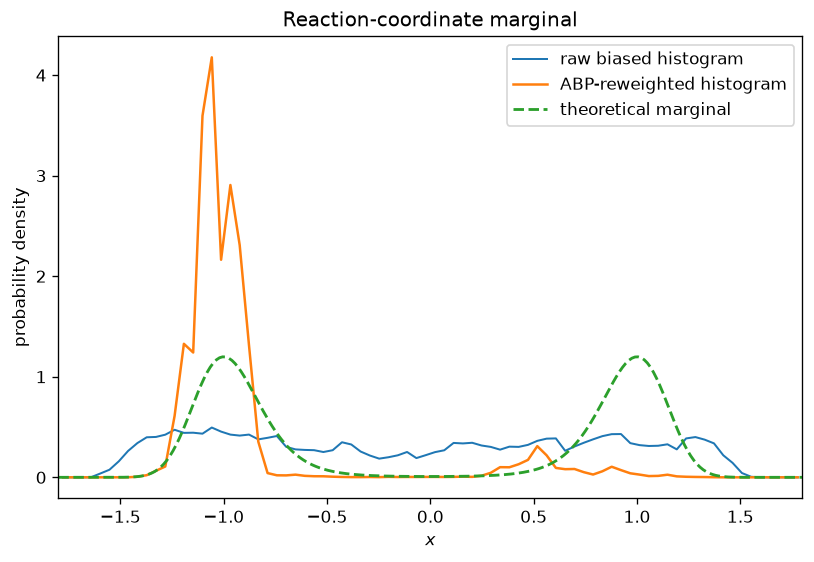

In [31]:
fig, ax = plt.subplots()
ax.plot(
    x_raw_centers,
    x_raw_density,
    linewidth=1.2,
    label="raw biased histogram",
)
ax.plot(
    x_weighted_centers,
    x_weighted_density,
    linewidth=1.5,
    label="ABP-reweighted histogram",
)
ax.plot(
    theory_x_coordinate,
    theory_x_density,
    linestyle="--",
    linewidth=1.7,
    label="theoretical marginal",
)
ax.set(
    xlabel=r"$x$",
    ylabel="probability density",
    title="Reaction-coordinate marginal",
    xlim=X_RANGE,
)
ax.legend()
plt.show()

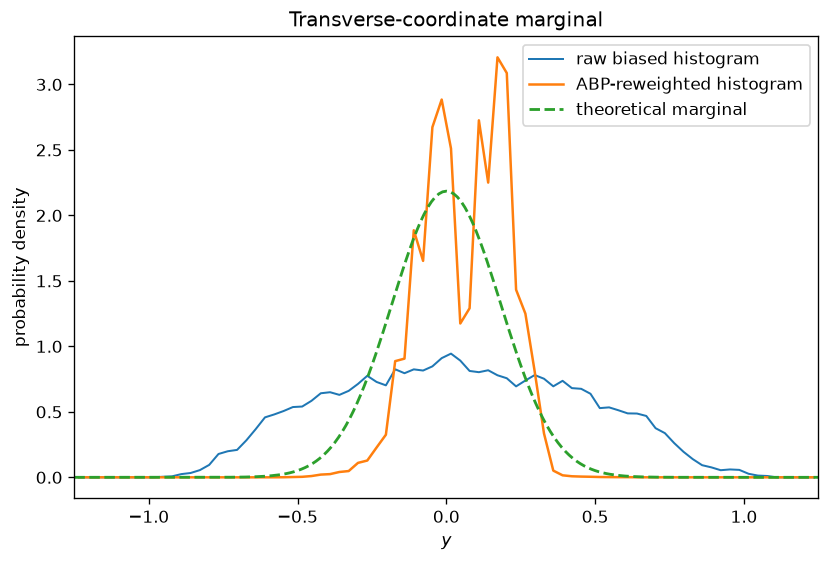

In [32]:
fig, ax = plt.subplots()
ax.plot(
    y_raw_centers,
    y_raw_density,
    linewidth=1.2,
    label="raw biased histogram",
)
ax.plot(
    y_weighted_centers,
    y_weighted_density,
    linewidth=1.5,
    label="ABP-reweighted histogram",
)
ax.plot(
    theory_y_coordinate,
    theory_y_density,
    linestyle="--",
    linewidth=1.7,
    label="theoretical marginal",
)
ax.set(
    xlabel=r"$y$",
    ylabel="probability density",
    title="Transverse-coordinate marginal",
    xlim=Y_RANGE,
)
ax.legend()
plt.show()

## 9. Quantitative distribution checks

The \(L^1\) distance between empirical and theoretical densities makes the
visual comparison reproducible. The reweighted error should generally be lower
than the raw biased error once the trajectory has visited both wells with
sufficient effective sample size.

In [33]:
def trapezoid(values: np.ndarray, coordinates: np.ndarray) -> float:
    implementation = getattr(np, "trapezoid", None)
    if implementation is None:
        implementation = np.trapz
    return float(implementation(values, coordinates))


def l1_error(
    empirical_coordinate: np.ndarray,
    empirical_density: np.ndarray,
    theoretical_coordinate: np.ndarray,
    theoretical_density: np.ndarray,
) -> float:
    reference = np.interp(
        empirical_coordinate,
        theoretical_coordinate,
        theoretical_density,
    )
    return trapezoid(
        np.abs(empirical_density - reference),
        empirical_coordinate,
    )


distribution_metrics = [
    {
        "coordinate": "x",
        "estimate": "raw biased",
        "L1_error": l1_error(
            x_raw_centers,
            x_raw_density,
            theory_x_coordinate,
            theory_x_density,
        ),
    },
    {
        "coordinate": "x",
        "estimate": "ABP reweighted",
        "L1_error": l1_error(
            x_weighted_centers,
            x_weighted_density,
            theory_x_coordinate,
            theory_x_density,
        ),
    },
    {
        "coordinate": "y",
        "estimate": "raw biased",
        "L1_error": l1_error(
            y_raw_centers,
            y_raw_density,
            theory_y_coordinate,
            theory_y_density,
        ),
    },
    {
        "coordinate": "y",
        "estimate": "ABP reweighted",
        "L1_error": l1_error(
            y_weighted_centers,
            y_weighted_density,
            theory_y_coordinate,
            theory_y_density,
        ),
    },
]

display(distribution_metrics)

[{'coordinate': 'x', 'estimate': 'raw biased', 'L1_error': 0.9235365113229668},
 {'coordinate': 'x',
  'estimate': 'ABP reweighted',
  'L1_error': 1.1174453623010376},
 {'coordinate': 'y', 'estimate': 'raw biased', 'L1_error': 0.8508745143979242},
 {'coordinate': 'y',
  'estimate': 'ABP reweighted',
  'L1_error': 0.5059674493513356}]

## 10. Reweighted clock and weight stability

The physical clock is accumulated as

$[
t_{\mathrm{phys}}=\sum_k w_k\,\Delta t.
]$

Plotting this clock and the weights reveals whether a small number of states
dominate the reweighting. The logarithmic weight scale is intentional.

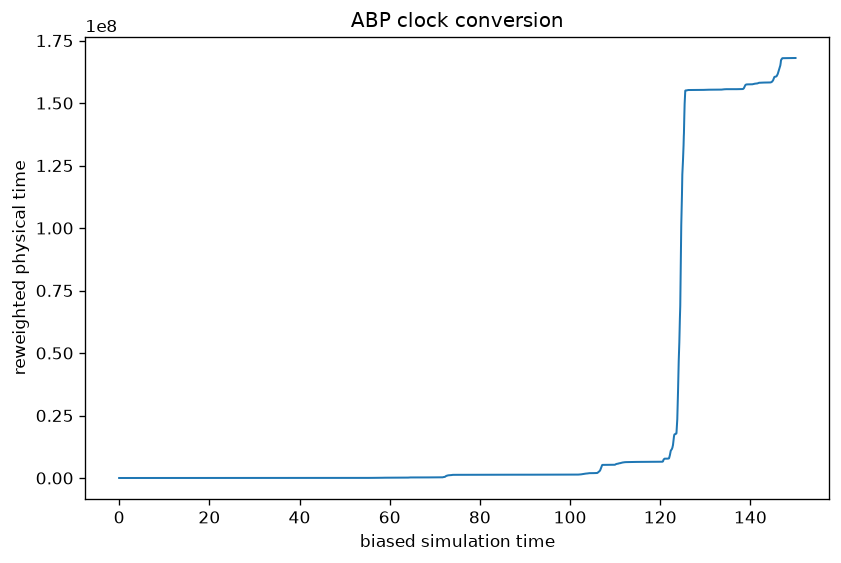

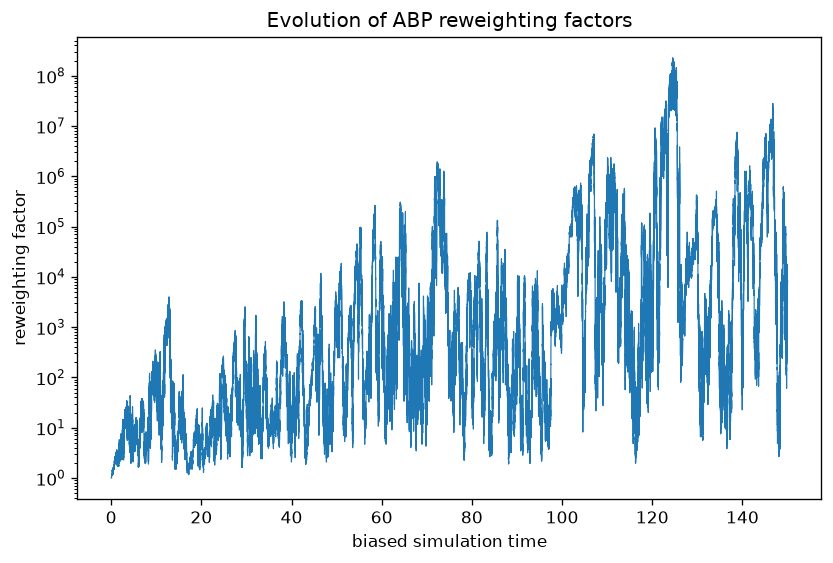

In [34]:
step_indices = np.arange(1, result.n_steps + 1)
cumulative_physical_time = np.cumsum(result.weights[1:]) * result.delta_t

fig, ax = plt.subplots()
ax.plot(
    step_indices * result.delta_t,
    cumulative_physical_time,
    linewidth=1.2,
)
ax.set(
    xlabel="biased simulation time",
    ylabel="reweighted physical time",
    title="ABP clock conversion",
)
plt.show()

fig, ax = plt.subplots()
ax.plot(
    step_indices * result.delta_t,
    result.weights[1:],
    linewidth=0.7,
)
ax.set_yscale("log")
ax.set(
    xlabel="biased simulation time",
    ylabel="reweighting factor",
    title="Evolution of ABP reweighting factors",
)
plt.show()

## 11. Interpretation checklist

A scientifically satisfactory run should show:

- visits to both metastable wells in the trajectory;
- Gaussian centers distributed through the explored region;
- a reduced effective barrier along \(y=0\);
- a clear difference between raw and reweighted histograms;
- reweighted \(x\)- and \(y\)-marginals reasonably close to theory;
- an ESS large enough that the result is not controlled by a few weights.

For report-quality conclusions, use `RUN_MODE = "reference"` and inspect the
ESS and \(L^1\) errors before exporting figures. If the ESS fraction is very
small, increase the trajectory length or retune `W`, `sigma`, and the
deposition stride rather than interpreting a visually smooth histogram as a
converged result.

## Refactoring notes

Compared with the exploratory version, this notebook now:

- uses the canonical `ABPMetaDynamics` and `Potential` APIs;
- consumes the immutable `ABPResult` instead of reading mutable simulator state;
- uses `run(max_steps=...)` with explicit total-step semantics;
- reconstructs the bias from result data;
- uses the repository's weighted-histogram and theoretical-marginal utilities;
- reports biased and physical clocks separately;
- makes reproducibility explicit through one seed and centralized parameters;
- keeps expensive execution, analysis, and plotting in independent sections;
- provides a persistence path for longer runs.